In [ ]:
from pathlib import Path
import pandas as pd
from google.colab import files

BASE_DIR = Path("/content/global_forest_project")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for old_file in DATA_DIR.glob("*"):
    if old_file.is_file():
        old_file.unlink()

uploaded_files = files.upload()

print(f"\nNumber of uploaded files: {len(uploaded_files)}")

for file_name, file_content in uploaded_files.items():
    file_path = DATA_DIR / file_name
    with open(file_path, "wb") as file:
        file.write(file_content)

print("\nUploaded files:")
uploaded_file_paths = sorted(DATA_DIR.glob("*"))
for file_path in uploaded_file_paths:
    print(file_path.name)

country_file_path = None
subnational_file_path = None

for file_path in uploaded_file_paths:
    normalized_name = file_path.name.lower().replace("_", " ").strip()

    if "country" in normalized_name and "tree cover loss" in normalized_name:
        country_file_path = file_path
    elif "subnational" in normalized_name and "tree cover loss" in normalized_name:
        subnational_file_path = file_path

if country_file_path is None or subnational_file_path is None:
    raise FileNotFoundError(
        "Could not identify the required files. "
        "Please upload one country tree cover loss file and one subnational tree cover loss file."
    )

print("\nDetected files:")
print("Country file:", country_file_path.name)
print("Subnational file:", subnational_file_path.name)

country_data_frame = pd.read_csv(country_file_path)
subnational_data_frame = pd.read_csv(subnational_file_path)

print("\nIndividual dataset shapes:")
print("Country dataset:", country_data_frame.shape)
print("Subnational dataset:", subnational_data_frame.shape)

print("\nFull-row duplicates before combining:")
print("Country dataset:", country_data_frame.duplicated().sum())
print("Subnational dataset:", subnational_data_frame.duplicated().sum())

country_key_duplicates = country_data_frame.duplicated(subset=["country", "threshold"]).sum()
subnational_key_duplicates = subnational_data_frame.duplicated(
    subset=["country", "subnational1", "threshold"]
).sum()

print("\nKey duplicates before combining:")
print("Country dataset:", country_key_duplicates)
print("Subnational dataset:", subnational_key_duplicates)

data_frame = pd.concat([country_data_frame, subnational_data_frame], ignore_index=True)

print("\nCombined dataset shape:")
print(data_frame.shape)

print("\nFirst 5 rows:")
print(data_frame.head())

print("\nColumn names:")
print(data_frame.columns.tolist())

missing_summary = data_frame.isna().sum().sort_values(ascending=False).reset_index()
missing_summary.columns = ["column_name", "missing_count"]
missing_summary["missing_percent"] = (
    (missing_summary["missing_count"] / len(data_frame)) * 100
).round(2)

print("\nMissing values summary:")
print(missing_summary)

loss_columns = [f"tc_loss_ha_{year}" for year in range(2001, 2023)]
available_loss_columns = [column for column in loss_columns if column in data_frame.columns]

selected_columns = [
    "country",
    "subnational1",
    "threshold",
    "area_ha",
    "extent_2000_ha",
    "extent_2010_ha",
    "gain_2000-2020_ha",
] + available_loss_columns

available_columns = [column for column in selected_columns if column in data_frame.columns]
selected_data_frame = data_frame[available_columns].copy()

print("\nAnnual loss columns available:")
print(available_loss_columns)

print("\nSelected columns:")
print(available_columns)

print("\nSelected dataset shape:")
print(selected_data_frame.shape)

numeric_data_frame = selected_data_frame.select_dtypes(include="number")
numeric_summary = numeric_data_frame.describe().T
numeric_summary["missing_count"] = numeric_data_frame.isna().sum()
numeric_summary["missing_percent"] = (
    (numeric_data_frame.isna().sum() / len(selected_data_frame)) * 100
).round(2)

print("\nBasic numeric statistics:")
print(numeric_summary)

text_data_frame = selected_data_frame.select_dtypes(include="object")
text_summary = pd.DataFrame({
    "column_name": text_data_frame.columns,
    "missing_count": text_data_frame.isna().sum().values,
    "missing_percent": (
        (text_data_frame.isna().sum() / len(selected_data_frame)) * 100
    ).round(2).values,
    "unique_values": text_data_frame.nunique(dropna=False).values,
})

print("\nBasic text statistics:")
print(text_summary)

selected_file = OUTPUT_DIR / "team_tree_cover_loss_selected.csv"
missing_file = OUTPUT_DIR / "team_tree_cover_loss_missing_summary.csv"
numeric_file = OUTPUT_DIR / "team_tree_cover_loss_numeric_summary.csv"
text_file = OUTPUT_DIR / "team_tree_cover_loss_text_summary.csv"

selected_data_frame.to_csv(selected_file, index=False)
missing_summary.to_csv(missing_file, index=False)
numeric_summary.to_csv(numeric_file)
text_summary.to_csv(text_file, index=False)

for file_name in [
    str(selected_file),
    str(missing_file),
    str(numeric_file),
    str(text_file),
]:
    print(file_name)

Saving Country tree cover loss.csv to Country tree cover loss (2).csv
Saving Subnational 1 tree cover loss.csv to Subnational 1 tree cover loss (2).csv

Number of uploaded files: 2

Uploaded files:
Country tree cover loss (2).csv
Subnational 1 tree cover loss (2).csv

Detected files:
Country file: Country tree cover loss (2).csv
Subnational file: Subnational 1 tree cover loss (2).csv

Individual dataset shapes:
Country dataset: (1888, 28)
Subnational dataset: (28000, 29)

Full-row duplicates before combining:
Country dataset: 0
Subnational dataset: 0

Key duplicates before combining:
Country dataset: 0
Subnational dataset: 0

Combined dataset shape:
(29888, 29)

First 5 rows:
       country  threshold   area_ha  extent_2000_ha  extent_2010_ha  \
0  Afghanistan          0  64385715        64385715        64385715   
1  Afghanistan         10  64385715          432115          126247   
2  Afghanistan         15  64385715          302660          106867   
3  Afghanistan         20  6438

The two deforestation files were successfully combined into a single dataset containing 29,888 rows and 29 columns. The dataset includes annual tree cover loss variables from 2001 to 2022, along with location and forest-related baseline variables. Initial inspection showed that the annual loss columns are complete, while missing values appear only in subnational1, which is expected for national-level records.

In [ ]:
clean_data_frame = data_frame.copy()

clean_data_frame["subnational1"] = clean_data_frame["subnational1"].fillna("National")

for column_name in ["country", "subnational1"]:
    blank_count = (clean_data_frame[column_name].astype(str).str.strip() == "").sum()
    print(f"Blank values in {column_name}: {blank_count}")

clean_data_frame["region_name"] = (
    clean_data_frame["country"].astype(str) + " | " + clean_data_frame["subnational1"].astype(str)
)

selected_columns = [
    "country",
    "subnational1",
    "region_name",
    "threshold",
    "area_ha",
    "extent_2000_ha",
    "extent_2010_ha",
    "gain_2000-2020_ha",
] + available_loss_columns

available_columns = [column for column in selected_columns if column in clean_data_frame.columns]
clean_data_frame = clean_data_frame[available_columns].copy()

print("Clean dataset shape:")
print(clean_data_frame.shape)

print("\nFirst 5 rows of clean dataset:")
print(clean_data_frame.head())

clean_missing_summary = clean_data_frame.isna().sum().sort_values(ascending=False).reset_index()
clean_missing_summary.columns = ["column_name", "missing_count"]
clean_missing_summary["missing_percent"] = (
    (clean_missing_summary["missing_count"] / len(clean_data_frame)) * 100
).round(2)

print("\nMissing values after cleaning:")
print(clean_missing_summary)

duplicate_key_columns = ["country", "subnational1", "threshold"]
duplicate_count = clean_data_frame.duplicated(subset=duplicate_key_columns).sum()

print(f"\nDuplicate rows based on country + subnational1 + threshold: {duplicate_count}")

duplicate_rows = clean_data_frame[
    clean_data_frame.duplicated(subset=duplicate_key_columns, keep=False)
].sort_values(duplicate_key_columns)

print("\nPreview of duplicate rows based on key columns:")
print(duplicate_rows.head(20))

numeric_check_columns = [
    "threshold",
    "area_ha",
    "extent_2000_ha",
    "extent_2010_ha",
    "gain_2000-2020_ha",
] + available_loss_columns

negative_summary = pd.DataFrame({
    "column_name": numeric_check_columns,
    "negative_count": [(clean_data_frame[column_name] < 0).sum() for column_name in numeric_check_columns],
})

print("\nNegative value summary:")
print(negative_summary)

threshold_summary = (
    clean_data_frame["threshold"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
threshold_summary.columns = ["threshold", "row_count"]

print("\nThreshold summary:")
print(threshold_summary)

clean_file = OUTPUT_DIR / "team_deforestation_clean.csv"
clean_missing_file = OUTPUT_DIR / "team_deforestation_clean_missing_summary.csv"
duplicate_file = OUTPUT_DIR / "team_deforestation_duplicate_rows.csv"
threshold_file = OUTPUT_DIR / "team_deforestation_threshold_summary.csv"
negative_file = OUTPUT_DIR / "team_deforestation_negative_summary.csv"

clean_data_frame.to_csv(clean_file, index=False)
clean_missing_summary.to_csv(clean_missing_file, index=False)
duplicate_rows.to_csv(duplicate_file, index=False)
threshold_summary.to_csv(threshold_file, index=False)
negative_summary.to_csv(negative_file, index=False)

for file_name in [
    str(clean_file),
    str(clean_missing_file),
    str(duplicate_file),
    str(threshold_file),
    str(negative_file),
]:
    print(file_name)

Blank values in country: 0
Blank values in subnational1: 0
Clean dataset shape:
(29888, 30)

First 5 rows of clean dataset:
       country subnational1             region_name  threshold   area_ha  \
0  Afghanistan     National  Afghanistan | National          0  64385715   
1  Afghanistan     National  Afghanistan | National         10  64385715   
2  Afghanistan     National  Afghanistan | National         15  64385715   
3  Afghanistan     National  Afghanistan | National         20  64385715   
4  Afghanistan     National  Afghanistan | National         25  64385715   

   extent_2000_ha  extent_2010_ha  gain_2000-2020_ha  tc_loss_ha_2001  \
0        64385715        64385715              10741              103   
1          432115          126247              10741               92   
2          302660          106867              10741               91   
3          284357          105733              10741               89   
4          254867           72395              10741  

The cleaned deforestation dataset contains 29,888 rows and 30 columns and is ready for threshold-based trajectory analysis. Filling missing subnational labels with National allowed us to create a consistent region_name field for all observations. We also confirmed that there are no duplicate region-threshold combinations, no blank values in the main geographic fields, and no negative values in the key numeric variables. Finally, each threshold level contains exactly 3,736 observations, which provides a clean and balanced structure for the next stage of threshold comparison and clustering.

In [ ]:
loss_columns = [f"tc_loss_ha_{year}" for year in range(2001, 2023)]
available_loss_columns = [column for column in loss_columns if column in clean_data_frame.columns]

thresholds_to_compare = [10, 30, 50]
comparison_rows = []

for threshold_value in thresholds_to_compare:
    threshold_subset = clean_data_frame[clean_data_frame["threshold"] == threshold_value].copy()
    numeric_subset = threshold_subset[available_loss_columns]

    total_loss_per_region = numeric_subset.sum(axis=1)
    relative_total_loss = (
        total_loss_per_region / threshold_subset["extent_2000_ha"].replace(0, pd.NA)
    ) * 100

    summary_row = {
        "threshold": threshold_value,
        "row_count": len(threshold_subset),
        "mean_extent_2000_ha": threshold_subset["extent_2000_ha"].mean(),
        "total_mean_loss": total_loss_per_region.mean(),
        "total_median_loss": total_loss_per_region.median(),
        "mean_relative_total_loss_pct": relative_total_loss.mean(),
        "mean_2001_loss": numeric_subset["tc_loss_ha_2001"].mean(),
        "mean_2012_loss": numeric_subset["tc_loss_ha_2012"].mean(),
        "mean_2022_loss": numeric_subset["tc_loss_ha_2022"].mean(),
    }

    comparison_rows.append(summary_row)

threshold_comparison = pd.DataFrame(comparison_rows)

print("Threshold comparison summary:")
print(threshold_comparison)

comparison_file = OUTPUT_DIR / "team_threshold_comparison_10_30_50.csv"
threshold_comparison.to_csv(comparison_file, index=False)

for file_name in [str(comparison_file)]:
    print(file_name)

Threshold comparison summary:
   threshold  row_count  mean_extent_2000_ha  total_mean_loss  \
0         10       3736         2.597620e+06    266488.162473   
1         30       3736         2.137727e+06    245967.422645   
2         50       3736         1.766185e+06    209987.943522   

   total_median_loss  mean_relative_total_loss_pct  mean_2001_loss  \
0             4852.5                      7.695399     7590.658191   
1             3605.0                     10.610537     7149.157655   
2             2845.0                     12.042981     6350.789615   

   mean_2012_loss  mean_2022_loss  
0    13455.881424    13527.924786  
1    12597.588597    12215.739561  
2    10994.267131    10192.641328  
/content/global_forest_project/outputs/team_threshold_comparison_10_30_50.csv


The threshold comparison shows that forest-loss results depend strongly on how forest is defined. Threshold 10 captures a larger forest base and therefore higher absolute loss, while threshold 50 is more restrictive and produces lower absolute loss but higher relative loss. Threshold 30 provides a reasonable middle-ground definition and was selected for the clustering analysis.

In [ ]:
loss_columns = [f"tc_loss_ha_{year}" for year in range(2001, 2023)]
available_loss_columns = [column for column in loss_columns if column in clean_data_frame.columns]

selected_threshold = 30

available_thresholds = sorted(clean_data_frame["threshold"].dropna().unique().tolist())
print("Available thresholds:")
print(available_thresholds)

if selected_threshold not in available_thresholds:
    raise ValueError(f"Threshold {selected_threshold} is not available in the dataset.")

threshold_data_frame = clean_data_frame[
    clean_data_frame["threshold"] == selected_threshold
].copy()

print("\nSelected threshold:")
print(selected_threshold)

print("\nShape after threshold filter:")
print(threshold_data_frame.shape)

print("\nFirst 5 rows after threshold filter:")
print(threshold_data_frame.head())

clustering_columns_with_context = [
    "country",
    "subnational1",
    "region_name",
    "area_ha",
    "extent_2000_ha",
] + available_loss_columns

final_clustering_data_frame = threshold_data_frame[clustering_columns_with_context].copy()

print("\nFinal clustering dataset shape:")
print(final_clustering_data_frame.shape)

print("\nFirst 5 rows of final clustering dataset:")
print(final_clustering_data_frame.head())

clustering_feature_columns = ["country", "subnational1", "region_name"] + available_loss_columns
final_clustering_features_data_frame = threshold_data_frame[clustering_feature_columns].copy()

print("\nFeature-only clustering dataset shape:")
print(final_clustering_features_data_frame.shape)

final_missing_summary = final_clustering_data_frame.isna().sum().sort_values(ascending=False).reset_index()
final_missing_summary.columns = ["column_name", "missing_count"]
final_missing_summary["missing_percent"] = (
    (final_missing_summary["missing_count"] / len(final_clustering_data_frame)) * 100
).round(2)

print("\nMissing values in final clustering dataset:")
print(final_missing_summary)

final_clustering_file = OUTPUT_DIR / f"team_deforestation_threshold_{selected_threshold}_clustering_ready.csv"
final_features_file = OUTPUT_DIR / f"team_deforestation_threshold_{selected_threshold}_features_only.csv"
final_missing_file = OUTPUT_DIR / f"team_deforestation_threshold_{selected_threshold}_missing_summary.csv"

final_clustering_data_frame.to_csv(final_clustering_file, index=False)
final_clustering_features_data_frame.to_csv(final_features_file, index=False)
final_missing_summary.to_csv(final_missing_file, index=False)

for file_name in [
    str(final_clustering_file),
    str(final_features_file),
    str(final_missing_file),
]:
    print(file_name)

Available thresholds:
[0, 10, 15, 20, 25, 30, 50, 75]

Selected threshold:
30

Shape after threshold filter:
(3736, 30)

First 5 rows after threshold filter:
                  country subnational1                       region_name  \
5             Afghanistan     National            Afghanistan | National   
13  Akrotiri and Dhekelia     National  Akrotiri and Dhekelia | National   
21                Albania     National                Albania | National   
29                Algeria     National                Algeria | National   
37                Andorra     National                Andorra | National   

    threshold    area_ha  extent_2000_ha  extent_2010_ha  gain_2000-2020_ha  \
5          30   64385715          205791           71797              10741   
13         30      23448             456             383                 42   
21         30    2873537          648680          589017              16472   
29         30  230804377         1223621          821606             

After filtering the cleaned data to threshold 30, we obtained one consistent deforestation trajectory per region. The resulting dataset includes 3,736 observations, the full 2001–2022 annual loss sequence, and the baseline size variables needed for normalization. Since no missing values remain, the dataset is ready for the clustering workflow.

### Adding countries areas to be able to normalize forest sizes

In [ ]:
final_clustering_file = OUTPUT_DIR / "team_deforestation_threshold_30_clustering_ready.csv"
df = pd.read_csv(final_clustering_file)

loss_columns = [column for column in df.columns if column.startswith("tc_loss_ha_")]

print("Clustering dataset shape:")
print(df.shape)

print("\nAnnual loss columns:")
print(loss_columns)

print("\nFirst 5 rows of clustering dataset:")
print(df.head())

zero_extent_count = (df["extent_2000_ha"] == 0).sum()
missing_extent_count = df["extent_2000_ha"].isna().sum()

print("\nForest extent checks before normalization:")
print("Rows with extent_2000_ha equal to 0:", zero_extent_count)
print("Rows with missing extent_2000_ha:", missing_extent_count)

df_model = df[(df["extent_2000_ha"] > 0) & (df["extent_2000_ha"].notna())].copy()

print("\nShape after removing invalid forest extent rows:")
print(df_model.shape)

df_normalized = df_model.copy()
df_normalized[loss_columns] = df_model[loss_columns].div(df_model["extent_2000_ha"], axis=0) * 100

print("\nFirst 5 rows of normalized dataset:")
print(df_normalized.head())

print("\nNormalized loss summary:")
print(df_normalized[loss_columns].describe().T[["mean", "min", "max"]])

X = df_normalized[loss_columns].values

print("\nFeature matrix shape:")
print(X.shape)

normalized_file = OUTPUT_DIR / "team_deforestation_threshold_30_normalized_by_extent.csv"
df_normalized.to_csv(normalized_file, index=False)

for file_name in [str(normalized_file)]:
    print(file_name)

Clustering dataset shape:
(3736, 27)

Annual loss columns:
['tc_loss_ha_2001', 'tc_loss_ha_2002', 'tc_loss_ha_2003', 'tc_loss_ha_2004', 'tc_loss_ha_2005', 'tc_loss_ha_2006', 'tc_loss_ha_2007', 'tc_loss_ha_2008', 'tc_loss_ha_2009', 'tc_loss_ha_2010', 'tc_loss_ha_2011', 'tc_loss_ha_2012', 'tc_loss_ha_2013', 'tc_loss_ha_2014', 'tc_loss_ha_2015', 'tc_loss_ha_2016', 'tc_loss_ha_2017', 'tc_loss_ha_2018', 'tc_loss_ha_2019', 'tc_loss_ha_2020', 'tc_loss_ha_2021', 'tc_loss_ha_2022']

First 5 rows of clustering dataset:
                 country subnational1                       region_name  \
0            Afghanistan     National            Afghanistan | National   
1  Akrotiri and Dhekelia     National  Akrotiri and Dhekelia | National   
2                Albania     National                Albania | National   
3                Algeria     National                Algeria | National   
4                Andorra     National                Andorra | National   

     area_ha  extent_2000_ha  tc_l

In [ ]:
print("Initial forest extent summary:")
print(df_model["extent_2000_ha"].describe())

minimum_extent_ha = 1000
df_model_filtered = df_model[df_model["extent_2000_ha"] >= minimum_extent_ha].copy()

print("\nMinimum forest extent threshold used:")
print(minimum_extent_ha)

print("\nShape before small-extent filter:")
print(df_model.shape)

print("\nShape after small-extent filter:")
print(df_model_filtered.shape)

df_normalized = df_model_filtered.copy()
df_normalized[loss_columns] = (
    df_model_filtered[loss_columns].div(df_model_filtered["extent_2000_ha"], axis=0) * 100
)

print("\nFirst 5 rows of filtered and normalized dataset:")
print(df_normalized.head())

print("\nNormalized loss summary after small-extent filter:")
print(df_normalized[loss_columns].describe().T[["mean", "min", "max"]])

X = df_normalized[loss_columns].values

print("\nFeature matrix shape after small-extent filter:")
print(X.shape)

filtered_normalized_file = OUTPUT_DIR / "team_deforestation_threshold_30_normalized_by_extent_filtered.csv"
df_normalized.to_csv(filtered_normalized_file, index=False)

for file_name in [str(filtered_normalized_file)]:
    print(file_name)

Initial forest extent summary:
count    3.460000e+03
mean     2.308251e+06
std      1.970642e+07
min      1.000000e+00
25%      7.924250e+03
50%      1.034015e+05
75%      6.167448e+05
max      7.612265e+08
Name: extent_2000_ha, dtype: float64

Minimum forest extent threshold used:
1000

Shape before small-extent filter:
(3460, 27)

Shape after small-extent filter:
(3029, 27)

First 5 rows of filtered and normalized dataset:
       country subnational1             region_name    area_ha  \
0  Afghanistan     National  Afghanistan | National   64385715   
2      Albania     National      Albania | National    2873537   
3      Algeria     National      Algeria | National  230804377   
4      Andorra     National      Andorra | National      45196   
5       Angola     National       Angola | National  124742298   

   extent_2000_ha  tc_loss_ha_2001  tc_loss_ha_2002  tc_loss_ha_2003  \
0          205791         0.042762         0.086981         0.118567   
2          648680         0.57

To align the clustering inputs with the project objective, annual tree cover loss was normalized by each region’s forest extent in 2000 rather than by total regional area. This made the features represent relative forest loss over time, which is more consistent with the idea of a deforestation trajectory. Because some regions had zero or extremely small initial forest extent, an additional filter of at least 1,000 hectares of forest in 2000 was applied before clustering. This reduced instability in the percentage-based features and left 3,029 region-level observations for modeling, producing a more reliable input matrix for PCA and K-Means clustering.

## Clustering

Components kept: 14
Variance explained: 0.901


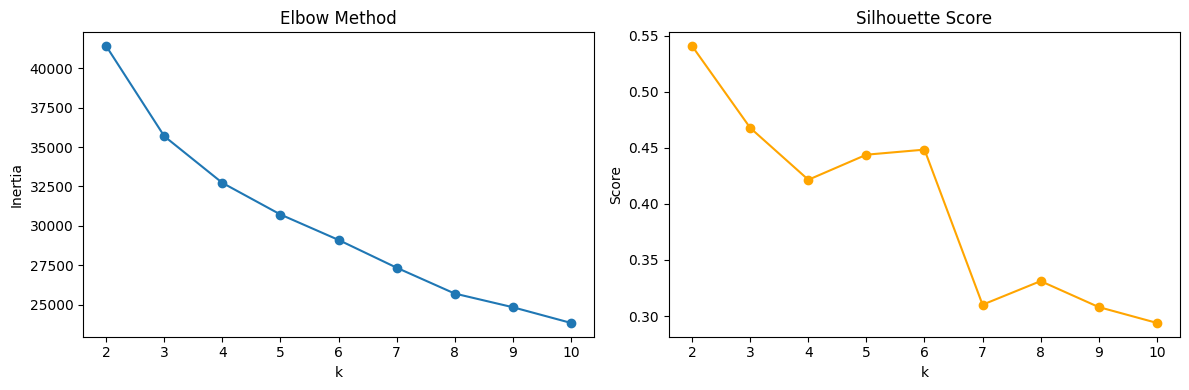

k=2: silhouette=0.541
k=3: silhouette=0.468
k=4: silhouette=0.422
k=5: silhouette=0.444
k=6: silhouette=0.449
k=7: silhouette=0.310
k=8: silhouette=0.331
k=9: silhouette=0.308
k=10: silhouette=0.294

Cluster sizes:
cluster
0     110
1    2217
2     702
Name: count, dtype: int64

Cluster mean trajectory profiles:
         tc_loss_ha_2001  tc_loss_ha_2002  tc_loss_ha_2003  tc_loss_ha_2004  \
cluster                                                                       
0                  1.817            1.922            1.707            2.037   
1                  0.221            0.160            0.146            0.216   
2                  0.512            0.513            0.427            0.576   

         tc_loss_ha_2005  tc_loss_ha_2006  tc_loss_ha_2007  tc_loss_ha_2008  \
cluster                                                                       
0                  1.690            1.976            2.086            1.864   
1                  0.193            0.189            

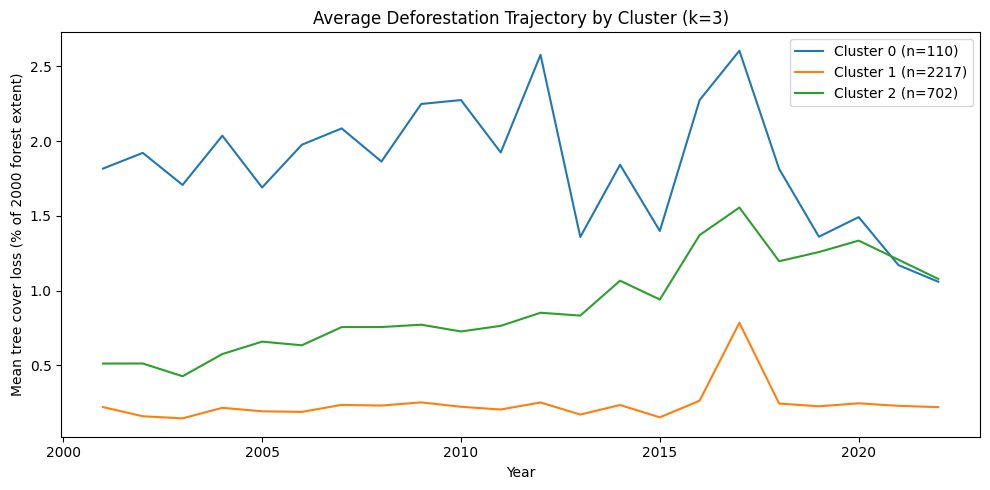


Cluster 0 (n=110) — countries with the most regions:
country
Portugal    18
Cambodia    11
Malaysia     9
Benin        7
Thailand     6
Name: count, dtype: int64

Cluster 1 (n=2217) — countries with the most regions:
country
Russia         79
Puerto Rico    77
Philippines    75
Turkey         65
Macedonia      62
Name: count, dtype: int64

Cluster 2 (n=702) — countries with the most regions:
country
Vietnam               35
Uganda                21
Ireland               20
Dominican Republic    20
Laos                  19
Name: count, dtype: int64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Components kept:", X_pca.shape[1])
print("Variance explained:", round(pca.explained_variance_ratio_.sum(), 3))

inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

for k, sil in zip(k_range, silhouette_values):
    print(f"k={k}: silhouette={sil:.3f}")

final_k = 3

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_normalized["cluster"] = kmeans.fit_predict(X_pca)

print("\nCluster sizes:")
print(df_normalized["cluster"].value_counts().sort_index())

cluster_profile = df_normalized.groupby("cluster")[loss_columns].mean()
print("\nCluster mean trajectory profiles:")
print(cluster_profile.round(3))

plt.figure(figsize=(10, 5))
for cluster_id in sorted(df_normalized["cluster"].unique()):
    plt.plot(
        range(2001, 2023),
        cluster_profile.loc[cluster_id],
        label=f"Cluster {cluster_id} (n={(df_normalized['cluster'] == cluster_id).sum()})"
    )

plt.xlabel("Year")
plt.ylabel("Mean tree cover loss (% of 2000 forest extent)")
plt.title("Average Deforestation Trajectory by Cluster (k=3)")
plt.legend()
plt.tight_layout()
plt.show()

# Show countries with the highest number of subnational observations in each cluster
for cluster_id in sorted(df_normalized["cluster"].unique()):
    print(f"\nCluster {cluster_id} (n={(df_normalized['cluster'] == cluster_id).sum()}) — countries with the most regions:")
    print(df_normalized[df_normalized["cluster"] == cluster_id]["country"].value_counts().head(5))

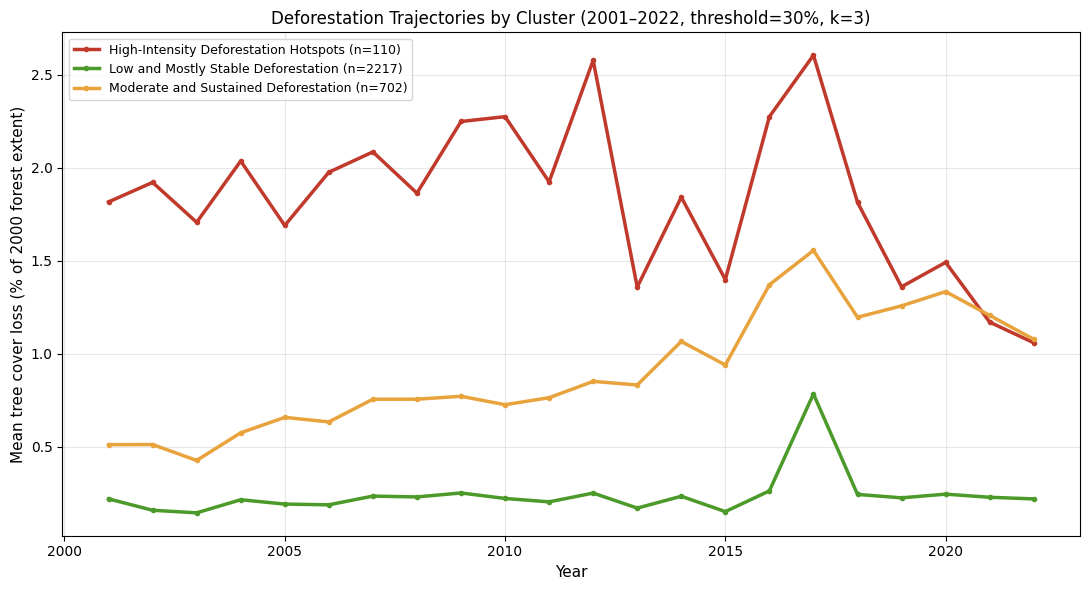

Saved chart to: /content/global_forest_project/outputs/team_deforestation_cluster_trajectories_labeled.png


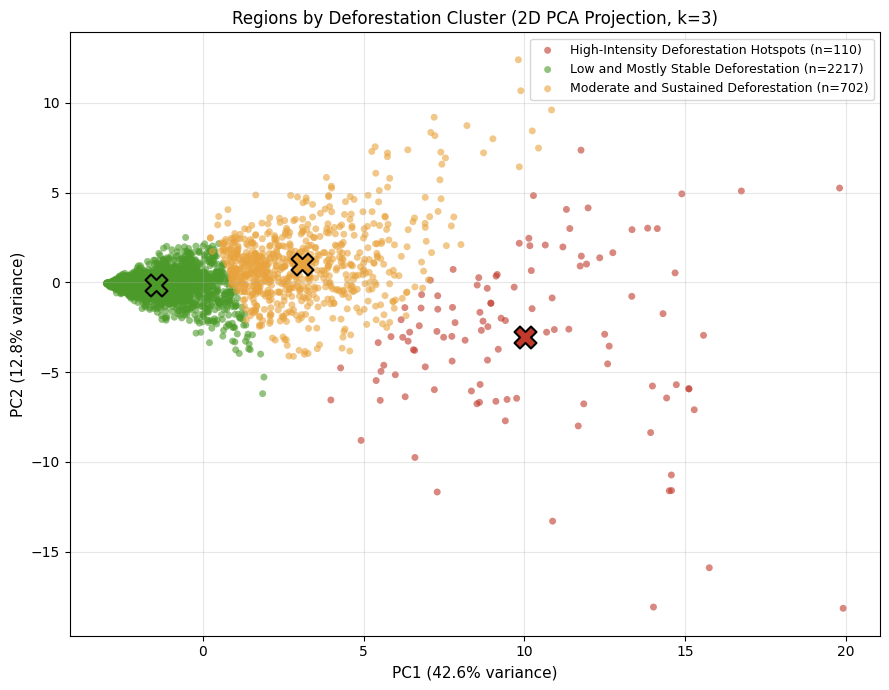

Saved chart to: /content/global_forest_project/outputs/team_deforestation_cluster_scatter.png


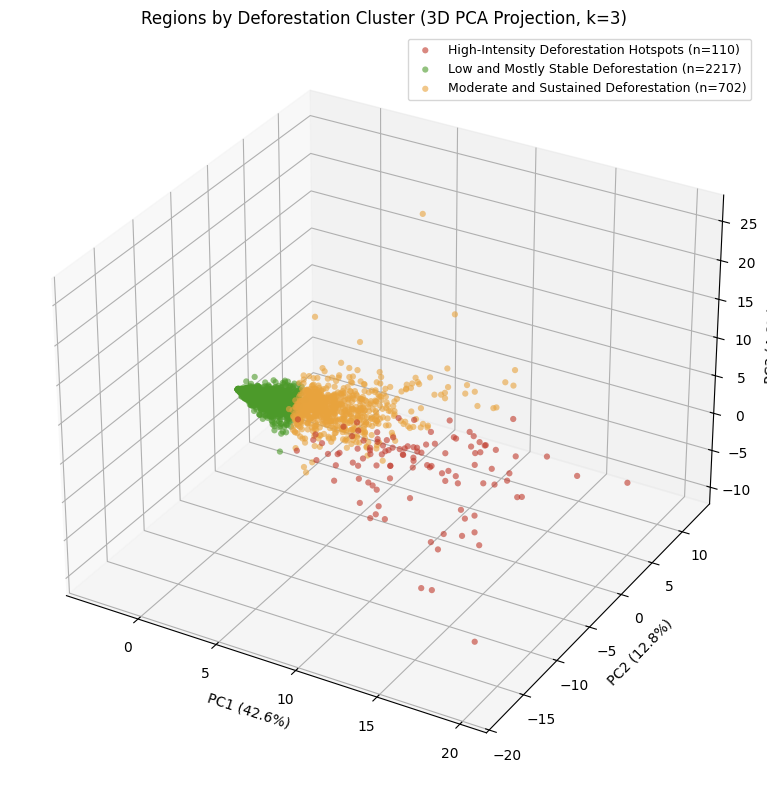

Saved chart to: /content/global_forest_project/outputs/team_deforestation_cluster_scatter_3d.png


In [ ]:
cluster_labels = {
    0: "High-Intensity Deforestation Hotspots",
    1: "Low and Mostly Stable Deforestation",
    2: "Moderate and Sustained Deforestation",
}

cluster_colors = {
    0: "#C0392B",  # red - high intensity
    1: "#4C9A2A",  # green - low loss
    2: "#E8A33D",  # amber - moderate
}

# 1. Mean trajectory by cluster
plt.figure(figsize=(11, 6))
for cluster_id in sorted(df_normalized["cluster"].unique()):
    n = (df_normalized["cluster"] == cluster_id).sum()
    plt.plot(
        range(2001, 2023),
        cluster_profile.loc[cluster_id],
        label=f"{cluster_labels[cluster_id]} (n={n})",
        color=cluster_colors[cluster_id],
        linewidth=2.5,
        marker="o",
        markersize=3,
    )

plt.xlabel("Year", fontsize=11)
plt.ylabel("Mean tree cover loss (% of 2000 forest extent)", fontsize=11)
plt.title("Deforestation Trajectories by Cluster (2001–2022, threshold=30%, k=3)", fontsize=12)
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

chart_file = OUTPUT_DIR / "team_deforestation_cluster_trajectories_labeled.png"
plt.savefig(chart_file, dpi=200)
plt.show()
print("Saved chart to:", chart_file)

# 2. 2D PCA scatter plot
plt.figure(figsize=(9, 7))

for cluster_id in sorted(df_normalized["cluster"].unique()):
    mask = df_normalized["cluster"] == cluster_id
    plt.scatter(
        X_pca[mask.values, 0],
        X_pca[mask.values, 1],
        s=25,
        alpha=0.6,
        color=cluster_colors[cluster_id],
        label=f"{cluster_labels[cluster_id]} (n={mask.sum()})",
        edgecolors="none",
    )

# Plot cluster centers in PCA space
centers_pca = kmeans.cluster_centers_
for cluster_id in sorted(df_normalized["cluster"].unique()):
    plt.scatter(
        centers_pca[cluster_id, 0],
        centers_pca[cluster_id, 1],
        s=250,
        marker="X",
        color=cluster_colors[cluster_id],
        edgecolors="black",
        linewidths=1.5,
        zorder=5,
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)", fontsize=11)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)", fontsize=11)
plt.title("Regions by Deforestation Cluster (2D PCA Projection, k=3)", fontsize=12)
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

scatter_file = OUTPUT_DIR / "team_deforestation_cluster_scatter.png"
plt.savefig(scatter_file, dpi=200)
plt.show()
print("Saved chart to:", scatter_file)

# 3. 3D PCA scatter plot
if X_pca.shape[1] >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id in sorted(df_normalized["cluster"].unique()):
        mask = (df_normalized["cluster"] == cluster_id).values
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            X_pca[mask, 2],
            s=20,
            alpha=0.6,
            color=cluster_colors[cluster_id],
            label=f"{cluster_labels[cluster_id]} (n={mask.sum()})",
            edgecolors="none",
            depthshade=False,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2] * 100:.1f}%)")
    ax.set_title("Regions by Deforestation Cluster (3D PCA Projection, k=3)")
    ax.legend(loc="best", fontsize=9)

    plt.tight_layout()

    scatter_3d_file = OUTPUT_DIR / "team_deforestation_cluster_scatter_3d.png"
    plt.savefig(scatter_3d_file, dpi=200)
    plt.show()
    print("Saved chart to:", scatter_3d_file)


PCA reduced the 22-year deforestation trajectories to 14 components while preserving about 90% of the total variance, making the clustering stage more efficient without discarding most of the information. K-Means was evaluated across several values of k, and although k = 2 produced the strongest silhouette score, k = 3 was chosen because it provided a more meaningful substantive segmentation. The resulting clusters suggest that the dominant difference across regions is the relative intensity of forest loss over time, with a large low-loss group, an intermediate sustained-loss group, and a small but distinct hotspot group.

**PCA Robustness Check**

In [ ]:
# Compare K-Means clustering with and without PCA
silhouette_values_nopca = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_values_nopca[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores without PCA:")
for k, sil in silhouette_values_nopca.items():
    print(f"k={k}: silhouette={sil:.3f}")

# Fit K-Means without PCA using the same final k
final_k = 3
kmeans_nopca = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_normalized["cluster_nopca"] = kmeans_nopca.fit_predict(X_scaled)

print("\nCluster sizes without PCA:")
print(df_normalized["cluster_nopca"].value_counts().sort_index())

# Align no-PCA cluster labels with PCA-based cluster meanings
cluster_nopca_mapping = {
    1: 0,  # hotspot
    0: 1,  # low-loss
    2: 2,  # moderate
}

df_normalized["cluster_nopca_aligned"] = df_normalized["cluster_nopca"].map(cluster_nopca_mapping)

comparison_table_aligned = pd.crosstab(
    df_normalized["cluster"],
    df_normalized["cluster_nopca_aligned"],
    rownames=["With PCA"],
    colnames=["Without PCA (aligned)"]
)

print("\nAligned cluster comparison table:")
print(comparison_table_aligned)

# Save comparison table
comparison_table_aligned_file = OUTPUT_DIR / "team_cluster_comparison_pca_vs_no_pca_aligned.csv"
comparison_table_aligned.to_csv(comparison_table_aligned_file)

# Created/Modified files during execution:
for file_name in [str(comparison_table_aligned_file)]:
    print(file_name)

Silhouette scores without PCA:
k=2: silhouette=0.521
k=3: silhouette=0.446
k=4: silhouette=0.399
k=5: silhouette=0.346
k=6: silhouette=0.333
k=7: silhouette=0.352
k=8: silhouette=0.343
k=9: silhouette=0.300
k=10: silhouette=0.263

Cluster sizes without PCA:
cluster_nopca
0    2216
1     112
2     701
Name: count, dtype: int64

Aligned cluster comparison table:
Without PCA (aligned)    0     1    2
With PCA                             
0                      110     0    0
1                        0  2216    1
2                        2     0  700
/content/global_forest_project/outputs/team_cluster_comparison_pca_vs_no_pca_aligned.csv


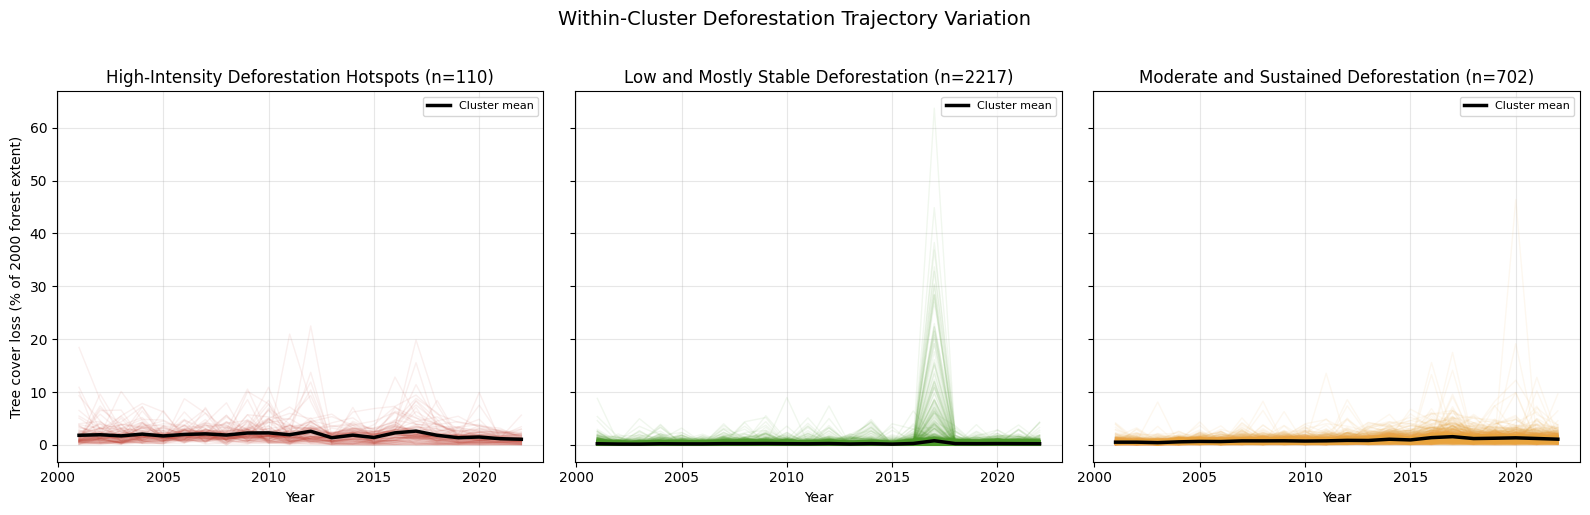

Saved chart to: /content/global_forest_project/outputs/team_deforestation_cluster_trajectory_spread.png


In [ ]:
# Visualize individual trajectories within each cluster
years = [int(column.replace("tc_loss_ha_", "")) for column in loss_columns]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
axes = axes.flatten()

for cluster_id in sorted(df_normalized["cluster"].unique()):
    ax = axes[cluster_id]
    members = df_normalized[df_normalized["cluster"] == cluster_id]

    # Plot individual trajectories
    for _, row in members.iterrows():
        ax.plot(
            years,
            row[loss_columns].values,
            color=cluster_colors[cluster_id],
            alpha=0.08,
            linewidth=1
        )

    # Plot cluster mean trajectory
    ax.plot(
        years,
        members[loss_columns].mean().values,
        color="black",
        linewidth=2.5,
        label="Cluster mean"
    )

    ax.set_title(f"{cluster_labels[cluster_id]} (n={len(members)})")
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Tree cover loss (% of 2000 forest extent)")

plt.suptitle("Within-Cluster Deforestation Trajectory Variation", y=1.02, fontsize=14)
plt.tight_layout()

spread_file = OUTPUT_DIR / "team_deforestation_cluster_trajectory_spread.png"
plt.savefig(spread_file, dpi=200)
plt.show()
print("Saved chart to:", spread_file)

PCA reduced the 22-year deforestation trajectories to 14 components while preserving about 90.1% of the total variance, making clustering more efficient without materially changing the underlying structure. K-Means was evaluated across several values of k, and although k = 2 produced the highest silhouette score, k = 3 was retained because it revealed a more substantively meaningful segmentation. The resulting clusters differ mainly in the relative intensity and stability of forest loss over time: a large low-loss and mostly stable group, an intermediate group with moderate and sustained deforestation, and a small hotspot group with higher and more volatile loss rates. The PCA projections and within-cluster trajectory plots visually support this interpretation, showing that the hotspot group is both more clearly separated and more internally heterogeneous than the broader low-loss baseline.

## 6.2 Random Forest: What Drives Forest Carbon Emissions?

**Approach:** predict `gross_emissions_MgCO2e_yr` (country level, threshold = 30%) from a set of tree-cover
and carbon-stock features. Random Forest handles the non-linear relationships and skewed distributions in
this kind of data well without needing manual transforms, and gives us feature importances / SHAP values to
explain *why* it predicts what it predicts — useful for showcasing which factors matter most for emissions.

In [ ]:
from google.colab import files

# Upload carbon files manually
uploaded_carbon_files = files.upload()

print(f"\nNumber of uploaded carbon files: {len(uploaded_carbon_files)}")

# Save uploaded carbon files into the data folder
for file_name, file_content in uploaded_carbon_files.items():
    file_path = DATA_DIR / file_name
    with open(file_path, "wb") as file:
        file.write(file_content)

print("\nUploaded carbon files:")
uploaded_carbon_file_paths = sorted(DATA_DIR.glob("*carbon*.csv"))
for file_path in uploaded_carbon_file_paths:
    print(file_path.name)

# Detect carbon files by flexible name matching
country_carbon_file = None
subnational_carbon_file = None

for file_path in uploaded_carbon_file_paths:
    normalized_name = file_path.name.lower().replace("_", " ").strip()

    if "country" in normalized_name and "carbon" in normalized_name:
        country_carbon_file = file_path
    elif "subnational" in normalized_name and "carbon" in normalized_name:
        subnational_carbon_file = file_path

if country_carbon_file is None or subnational_carbon_file is None:
    raise FileNotFoundError(
        "Could not identify the required carbon files. "
        "Please upload one country carbon file and one subnational carbon file."
    )

print("\nDetected carbon files:")
print("Country carbon file:", country_carbon_file.name)
print("Subnational carbon file:", subnational_carbon_file.name)

# Load carbon datasets
country_carbon = pd.read_csv(country_carbon_file)
subnational_carbon = pd.read_csv(subnational_carbon_file)

print("\nCountry carbon dataset shape:")
print(country_carbon.shape)

print("\nSubnational carbon dataset shape:")
print(subnational_carbon.shape)

print("\nFirst 5 rows of country carbon dataset:")
print(country_carbon.head())

print("\nFirst 5 rows of subnational carbon dataset:")
print(subnational_carbon.head())

# Created/Modified files during execution:
for file_name in []:
    print(file_name)

Saving Country carbon data.csv to Country carbon data.csv
Saving Subnational 1 carbon data.csv to Subnational 1 carbon data.csv

Number of uploaded carbon files: 2

Uploaded carbon files:
Country carbon data.csv
Subnational 1 carbon data.csv

Detected carbon files:
Country carbon file: Country carbon data.csv
Subnational carbon file: Subnational 1 carbon data.csv

Country carbon dataset shape:
(1888, 30)

Subnational carbon dataset shape:
(28000, 31)

First 5 rows of country carbon dataset:
       country  umd_tree_cover_density_2000__threshold  \
0  Afghanistan                                       0   
1  Afghanistan                                      10   
2  Afghanistan                                      15   
3  Afghanistan                                      20   
4  Afghanistan                                      25   

   umd_tree_cover_extent_2000__ha  gfw_aboveground_carbon_stocks_2000__Mg_C  \
0                        64385715                                  25912558 

In [ ]:
# Standardize threshold column name
country_carbon = country_carbon.rename(columns={"umd_tree_cover_density_2000__threshold": "threshold"})
subnational_carbon = subnational_carbon.rename(columns={"umd_tree_cover_density_2000__threshold": "threshold"})

# Rename key carbon columns
carbon_rename = {
    "umd_tree_cover_extent_2000__ha": "extent_2000_ha",
    "gfw_aboveground_carbon_stocks_2000__Mg_C": "carbon_stocks_2000_MgC",
    "avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1": "avg_carbon_stocks_2000_MgC_ha",
    "gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1": "gross_emissions_MgCO2e_yr",
    "gfw_forest_carbon_gross_removals__Mg_CO2_yr-1": "gross_removals_MgCO2_yr",
    "gfw_forest_carbon_net_flux__Mg_CO2e_yr-1": "net_flux_MgCO2e_yr",
}

country_carbon = country_carbon.rename(columns=carbon_rename)
subnational_carbon = subnational_carbon.rename(columns=carbon_rename)

print("Standardized country carbon columns:")
print(country_carbon.columns.tolist())

print("\nStandardized subnational carbon columns:")
print(subnational_carbon.columns.tolist())

# Check duplicate keys
country_carbon_key_duplicates = country_carbon.duplicated(subset=["country", "threshold"]).sum()
subnational_carbon_key_duplicates = subnational_carbon.duplicated(
    subset=["country", "subnational1", "threshold"]
).sum()

print("\nCountry carbon duplicate keys:")
print(country_carbon_key_duplicates)

print("\nSubnational carbon duplicate keys:")
print(subnational_carbon_key_duplicates)

# Check missing values by threshold for main carbon variables
carbon_variables = [
    "gross_emissions_MgCO2e_yr",
    "gross_removals_MgCO2_yr",
    "net_flux_MgCO2e_yr",
]

print("\nCountry carbon missing share by threshold:")
country_missing_by_threshold = country_carbon.groupby("threshold")[carbon_variables].apply(
    lambda df: df.isna().mean().round(3)
)
print(country_missing_by_threshold)

print("\nSubnational carbon missing share by threshold:")
subnational_missing_by_threshold = subnational_carbon.groupby("threshold")[carbon_variables].apply(
    lambda df: df.isna().mean().round(3)
)
print(subnational_missing_by_threshold)

# Save cleaned carbon files
country_carbon_clean_file = OUTPUT_DIR / "team_country_carbon_standardized.csv"
subnational_carbon_clean_file = OUTPUT_DIR / "team_subnational_carbon_standardized.csv"

country_carbon.to_csv(country_carbon_clean_file, index=False)
subnational_carbon.to_csv(subnational_carbon_clean_file, index=False)

# Created/Modified files during execution:
for file_name in [
    str(country_carbon_clean_file),
    str(subnational_carbon_clean_file),
]:
    print(file_name)


Standardized country carbon columns:
['country', 'threshold', 'extent_2000_ha', 'carbon_stocks_2000_MgC', 'avg_carbon_stocks_2000_MgC_ha', 'gross_emissions_MgCO2e_yr', 'gross_removals_MgCO2_yr', 'net_flux_MgCO2e_yr', 'gfw_forest_carbon_gross_emissions_2001__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2002__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2003__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2004__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2005__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2006__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2007__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2008__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2009__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2010__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2011__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2012__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2013__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2014__Mg_CO2e', 'gfw_forest_carbon_gross_emissions_2015__Mg_CO2e', 'gfw_forest_carbon

The carbon datasets were successfully standardized and structurally validated. Duplicate-key checks confirmed that both the country-level and subnational-level carbon tables are uniquely defined by their geographic-threshold identifiers. The missing-value pattern also revealed that the main carbon outcome variables ('gross_emissions_MgCO2e_yr', 'gross_removals_MgCO2_yr', and 'net_flux_MgCO2e_yr') are fully missing at thresholds 0–25 and fully populated at thresholds 30, 50, and 75. This confirms that the missingness is structural rather than accidental and supports the decision to use threshold 30 for the carbon analysis, keeping it consistent with the main deforestation-clustering workflow.

In [ ]:
# Filter carbon datasets to threshold 30
selected_threshold = 30

country_carbon_30 = country_carbon[country_carbon["threshold"] == selected_threshold].copy()
subnational_carbon_30 = subnational_carbon[subnational_carbon["threshold"] == selected_threshold].copy()

print("Country carbon shape at threshold 30:")
print(country_carbon_30.shape)

print("\nSubnational carbon shape at threshold 30:")
print(subnational_carbon_30.shape)

print("\nFirst 5 rows of country carbon at threshold 30:")
print(country_carbon_30.head())

# Prepare country-level deforestation data at threshold 30
country_deforestation_30 = clean_data_frame[
    (clean_data_frame["threshold"] == selected_threshold) &
    (clean_data_frame["subnational1"] == "National")
].copy()

print("\nCountry deforestation shape at threshold 30:")
print(country_deforestation_30.shape)

print("\nFirst 5 rows of country deforestation at threshold 30:")
print(country_deforestation_30.head())

# Check merge keys
print("\nUnique countries in country deforestation:")
print(country_deforestation_30["country"].nunique())

print("\nUnique countries in country carbon:")
print(country_carbon_30["country"].nunique())

# Save filtered files
country_carbon_30_file = OUTPUT_DIR / "team_country_carbon_threshold_30.csv"
subnational_carbon_30_file = OUTPUT_DIR / "team_subnational_carbon_threshold_30.csv"
country_deforestation_30_file = OUTPUT_DIR / "team_country_deforestation_threshold_30.csv"

country_carbon_30.to_csv(country_carbon_30_file, index=False)
subnational_carbon_30.to_csv(subnational_carbon_30_file, index=False)
country_deforestation_30.to_csv(country_deforestation_30_file, index=False)

# Created/Modified files during execution:
for file_name in [
    str(country_carbon_30_file),
    str(subnational_carbon_30_file),
    str(country_deforestation_30_file),
]:
    print(file_name)

Country carbon shape at threshold 30:
(236, 30)

Subnational carbon shape at threshold 30:
(3500, 31)

First 5 rows of country carbon at threshold 30:
                  country  threshold  extent_2000_ha  carbon_stocks_2000_MgC  \
5             Afghanistan         30          205791                12410476   
13  Akrotiri and Dhekelia         30             456                   20529   
21                Albania         30          648680                40971858   
29                Algeria         30         1223621                64837658   
37                Andorra         30           19004                 1556611   

    avg_carbon_stocks_2000_MgC_ha  gross_emissions_MgCO2e_yr  \
5                              60                    16684.0   
13                             45                      618.0   
21                             63                   710878.0   
29                             53                  3010948.0   
37                             82               

In [ ]:
# Merge country-level deforestation and carbon data at threshold 30
country_merged_30 = country_deforestation_30.merge(
    country_carbon_30,
    on=["country", "threshold"],
    how="inner",
    suffixes=("_loss", "_carbon")
)

print("Merged country-level dataset shape:")
print(country_merged_30.shape)

print("\nFirst 5 rows of merged dataset:")
print(country_merged_30.head())

# Rebuild annual loss column list from the country deforestation table
loss_columns_country = [column for column in country_deforestation_30.columns if column.startswith("tc_loss_ha_")]

# Feature engineering: cumulative and period-specific loss
country_merged_30["cumulative_loss_ha"] = country_merged_30[loss_columns_country].sum(axis=1)

early_loss_columns = [f"tc_loss_ha_{year}" for year in range(2001, 2006)]
recent_loss_columns = [f"tc_loss_ha_{year}" for year in range(2018, 2023)]

country_merged_30["early_loss_ha"] = country_merged_30[early_loss_columns].sum(axis=1)
country_merged_30["recent_loss_ha"] = country_merged_30[recent_loss_columns].sum(axis=1)

print("\nEngineered features preview:")
print(
    country_merged_30[
        ["country", "cumulative_loss_ha", "early_loss_ha", "recent_loss_ha", "gross_emissions_MgCO2e_yr"]
    ].head()
)

# Check missing values in the main modeling variables
model_columns = [
    "extent_2000_ha_loss",
    "gain_2000-2020_ha",
    "cumulative_loss_ha",
    "early_loss_ha",
    "recent_loss_ha",
    "carbon_stocks_2000_MgC",
    "avg_carbon_stocks_2000_MgC_ha",
    "gross_emissions_MgCO2e_yr",
]

model_missing_summary = country_merged_30[model_columns].isna().sum().reset_index()
model_missing_summary.columns = ["column_name", "missing_count"]
model_missing_summary["missing_percent"] = (
    model_missing_summary["missing_count"] / len(country_merged_30) * 100
).round(2)

print("\nMissing values in modeling columns:")
print(model_missing_summary)

# Save merged dataset
country_merged_30_file = OUTPUT_DIR / "team_country_deforestation_carbon_merged_threshold_30.csv"
country_merged_30.to_csv(country_merged_30_file, index=False)

# Created/Modified files during execution:
for file_name in [str(country_merged_30_file)]:
    print(file_name)

Merged country-level dataset shape:
(236, 58)

First 5 rows of merged dataset:
                 country subnational1                       region_name  \
0            Afghanistan     National            Afghanistan | National   
1  Akrotiri and Dhekelia     National  Akrotiri and Dhekelia | National   
2                Albania     National                Albania | National   
3                Algeria     National                Algeria | National   
4                Andorra     National                Andorra | National   

   threshold    area_ha  extent_2000_ha_loss  extent_2010_ha  \
0         30   64385715               205791           71797   
1         30      23448                  456             383   
2         30    2873537               648680          589017   
3         30  230804377              1223621          821606   
4         30      45196                19004           18962   

   gain_2000-2020_ha  tc_loss_ha_2001  tc_loss_ha_2002  ...  \
0              10741  

The country-level deforestation and carbon datasets merged cleanly at the 30% threshold, producing a complete modeling table with 236 country-level observations and no missing values in the main analysis variables. This confirms that the merged dataset is structurally suitable for exploring the relationship between forest loss and carbon emissions and for building predictive models of gross forest emissions.

# Absolute vs. relative loss comparison conclusion
To define better dependent variable to work with

Comparison dataset shape:
(217, 4)

First 5 rows:
                 country  cumulative_loss_ha  cumulative_loss_pct  \
0            Afghanistan                1886             0.916464   
1  Akrotiri and Dhekelia                  38             8.333333   
2                Albania               43946             6.774681   
3                Algeria              205264            16.775129   
4                Andorra                 132             0.694591   

   gross_emissions_MgCO2e_yr  
0                    16684.0  
1                      618.0  
2                   710878.0  
3                  3010948.0  
4                     3391.0  

Pearson correlation with gross emissions:
Absolute cumulative loss (ha): 0.895
Relative cumulative loss (% of 2000 extent): 0.073


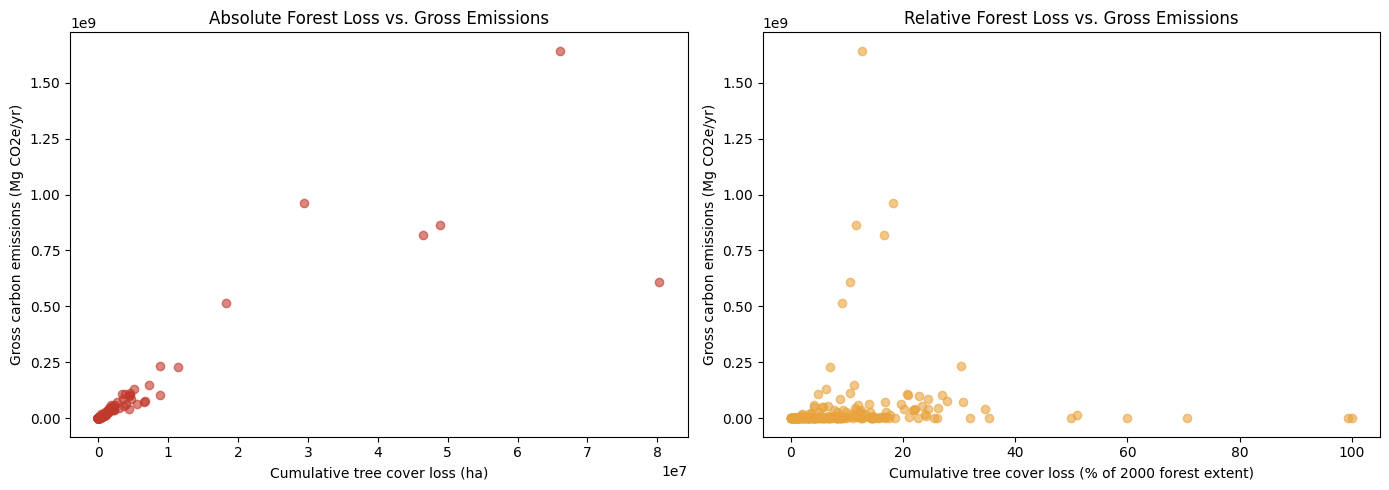

/content/global_forest_project/outputs/team_absolute_vs_relative_loss_emissions_comparison.csv


In [ ]:
import matplotlib.pyplot as plt

# Rebuild annual loss columns if needed
loss_columns_country = [column for column in country_merged_30.columns if column.startswith("tc_loss_ha_")]

# Create absolute and relative cumulative loss measures
country_merged_30["cumulative_loss_ha"] = country_merged_30[loss_columns_country].sum(axis=1)
country_merged_30["cumulative_loss_pct"] = (
    country_merged_30["cumulative_loss_ha"] / country_merged_30["extent_2000_ha_loss"] * 100
)

# Check for invalid values
comparison_data = country_merged_30[
    ["country", "cumulative_loss_ha", "cumulative_loss_pct", "gross_emissions_MgCO2e_yr"]
].dropna()

print("Comparison dataset shape:")
print(comparison_data.shape)

print("\nFirst 5 rows:")
print(comparison_data.head())

# Compute correlations
absolute_corr = comparison_data["cumulative_loss_ha"].corr(comparison_data["gross_emissions_MgCO2e_yr"])
relative_corr = comparison_data["cumulative_loss_pct"].corr(comparison_data["gross_emissions_MgCO2e_yr"])

print("\nPearson correlation with gross emissions:")
print(f"Absolute cumulative loss (ha): {absolute_corr:.3f}")
print(f"Relative cumulative loss (% of 2000 extent): {relative_corr:.3f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    comparison_data["cumulative_loss_ha"],
    comparison_data["gross_emissions_MgCO2e_yr"],
    alpha=0.6,
    color="#C0392B"
)
axes[0].set_xlabel("Cumulative tree cover loss (ha)")
axes[0].set_ylabel("Gross carbon emissions (Mg CO2e/yr)")
axes[0].set_title("Absolute Forest Loss vs. Gross Emissions")

axes[1].scatter(
    comparison_data["cumulative_loss_pct"],
    comparison_data["gross_emissions_MgCO2e_yr"],
    alpha=0.6,
    color="#E8A33D"
)
axes[1].set_xlabel("Cumulative tree cover loss (% of 2000 forest extent)")
axes[1].set_ylabel("Gross carbon emissions (Mg CO2e/yr)")
axes[1].set_title("Relative Forest Loss vs. Gross Emissions")

plt.tight_layout()
plt.show()

# Save comparison data
comparison_output_file = OUTPUT_DIR / "team_absolute_vs_relative_loss_emissions_comparison.csv"
comparison_data.to_csv(comparison_output_file, index=False)

# Created/Modified files during execution:
for file_name in [str(comparison_output_file)]:
    print(file_name)

The comparison between cumulative absolute forest loss and cumulative relative forest loss showed a major difference in their relationship to gross carbon emissions. Absolute cumulative loss was very strongly correlated with emissions (r = 0.895), while relative cumulative loss showed almost no linear relationship (r = 0.073). This suggests that absolute forest loss is a much more informative predictor of country-level gross emissions, which is consistent with the fact that emissions are also measured in absolute terms.

#Predictive models comparison
They are compared 2 models, Linear Regression and Random Forest to evaluate predictability and study feature importance


Modeling dataset shape:
(236, 8)

First 5 rows of modeling dataset:
   extent_2000_ha_loss  gain_2000-2020_ha  cumulative_loss_ha  early_loss_ha  \
0               205791              10741                1886            948   
1                  456                 42                  38              5   
2               648680              16472               43946           9165   
3              1223621              89152              205264          19154   
4                19004                120                 132             28   

   recent_loss_ha  carbon_stocks_2000_MgC  avg_carbon_stocks_2000_MgC_ha  \
0             112                12410476                             60   
1               4                   20529                             45   
2            8022                40971858                             63   
3           59044                64837658                             53   
4              67                 1556611                             8

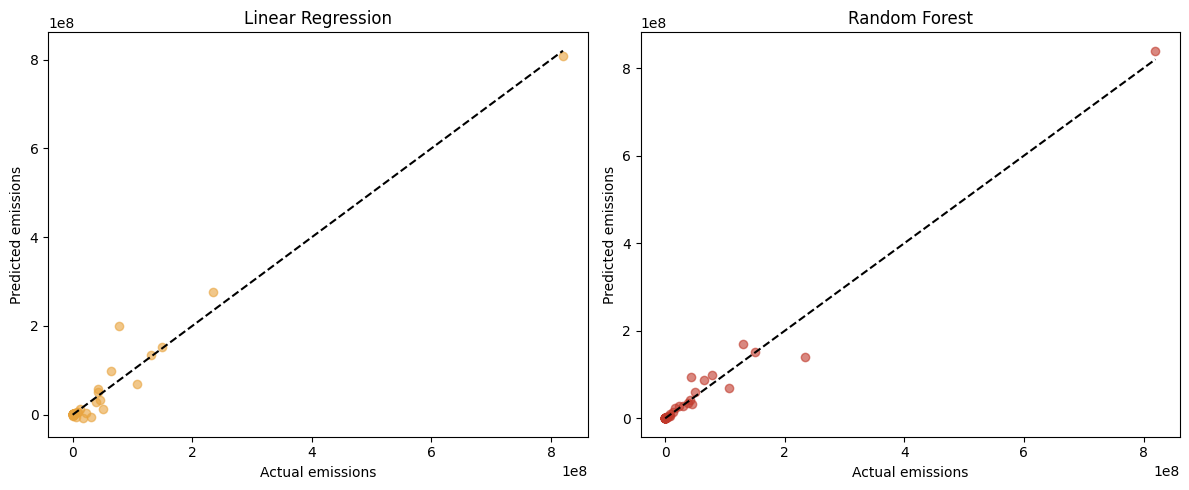

/content/global_forest_project/outputs/team_emissions_model_comparison.csv


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define features and target
features = [
    "extent_2000_ha_loss",
    "gain_2000-2020_ha",
    "cumulative_loss_ha",
    "early_loss_ha",
    "recent_loss_ha",
    "carbon_stocks_2000_MgC",
    "avg_carbon_stocks_2000_MgC_ha",
]

target = "gross_emissions_MgCO2e_yr"

# Prepare modeling dataset
model_df = country_merged_30[features + [target]].dropna().copy()

print("Modeling dataset shape:")
print(model_df.shape)

print("\nFirst 5 rows of modeling dataset:")
print(model_df.head())

# Split data
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:")
print(X_train.shape)

print("\nTesting set shape:")
print(X_test.shape)

# Train Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

# Train Random Forest
random_forest_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)

# Evaluate both models
results = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest"],
    "r2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, random_forest_predictions),
    ],
    "mae": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, random_forest_predictions),
    ],
    "rmse": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, random_forest_predictions)),
    ],
})

print("\nModel comparison:")
print(results)

# Identify best model by R²
best_model_row = results.sort_values(by="r2", ascending=False).iloc[0]

print("\nBest model based on highest R²:")
print(best_model_row["model"])

# Plot predicted vs actual for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, linear_predictions, alpha=0.6, color="#E8A33D")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--"
)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual emissions")
axes[0].set_ylabel("Predicted emissions")

axes[1].scatter(y_test, random_forest_predictions, alpha=0.6, color="#C0392B")
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--"
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual emissions")
axes[1].set_ylabel("Predicted emissions")

plt.tight_layout()
plt.show()

# Save model comparison results
model_comparison_file = OUTPUT_DIR / "team_emissions_model_comparison.csv"
results.to_csv(model_comparison_file, index=False)

# Created/Modified files during execution:
for file_name in [str(model_comparison_file)]:
    print(file_name)

Both Linear Regression and Random Forest performed strongly in predicting country-level gross forest carbon emissions, with Random Forest showing slightly better performance across all evaluation metrics. This indicates that the selected forest-loss and carbon-stock variables contain substantial information about emissions levels. However, because the target variable is conceptually related to forest clearing and carbon density, the model should be interpreted primarily as an explanatory predictive tool rather than as evidence of independent causal discovery.

Random Forest feature importance:
                         feature  importance
2             cumulative_loss_ha    0.245777
5         carbon_stocks_2000_MgC    0.217537
4                 recent_loss_ha    0.174977
3                  early_loss_ha    0.163507
0            extent_2000_ha_loss    0.149687
1              gain_2000-2020_ha    0.048086
6  avg_carbon_stocks_2000_MgC_ha    0.000430


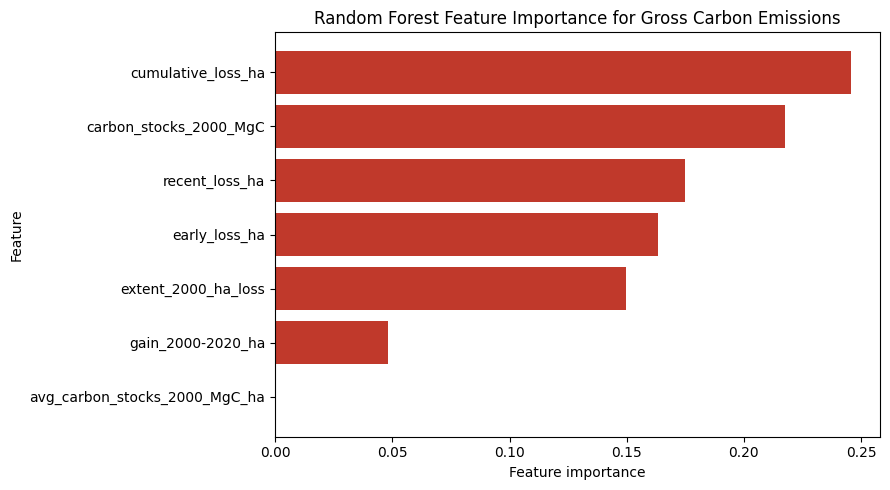

/content/global_forest_project/outputs/team_random_forest_feature_importance.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from the trained Random Forest model
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest_model.feature_importances_,
}).sort_values(by="importance", ascending=False)

print("Random Forest feature importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(9, 5))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1],
    color="#C0392B"
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance for Gross Carbon Emissions")
plt.tight_layout()
plt.show()

# Save feature importance table
feature_importance_file = OUTPUT_DIR / "team_random_forest_feature_importance.csv"
feature_importance.to_csv(feature_importance_file, index=False)

# Created/Modified files during execution:
for file_name in [str(feature_importance_file)]:
    print(file_name)

The Random Forest feature importance ranking shows that cumulative forest loss is the strongest predictor of gross carbon emissions, followed by total baseline carbon stocks, recent forest loss, and early-period forest loss. This suggests that emissions are driven primarily by the absolute scale of forest clearing, while baseline carbon availability also plays a major role. In contrast, forest gain contributes relatively little, and average carbon density per hectare adds almost no additional predictive value once the other variables are included.